In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load the feature-engineered data
df = pd.read_csv('../data/processed/telco_churn_with_features.csv')

print("✅ Feature-engineered data loaded successfully!")
print(f"Dataset Shape: {df.shape}")
print("\nFirst few rows:")
df.head()

✅ Feature-engineered data loaded successfully!
Dataset Shape: (7043, 50)

First few rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,uses_auto_payment,has_family,family_size,senior_with_dependents,single_senior,customer_profile,churn_risk_score,is_high_risk,value_risk_ratio,engagement_per_dollar
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,0,1,2,0,0,Adult with Family,9,1,2.985,0.067002
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,0,0,1,0,0,Adult Alone,1,0,944.750,0.070237
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,0,0,1,0,0,Adult Alone,6,1,15.450,0.074280
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,1,0,1,0,0,Adult Alone,1,0,920.375,0.094563
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,0,0,1,0,0,Adult Alone,9,1,15.165,0.028289


In [2]:
# Prepare data for clustering
print("PREPARING DATA FOR CLUSTERING")
print("="*50)

# Select features for clustering
# We'll use numeric features that capture customer behavior
clustering_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'total_services',
    'contract_level',
    'is_new_customer',
    'has_internet',
    'has_streaming',
    'uses_auto_payment',
    'family_size',
    'churn_risk_score'
]

# Create clustering dataset
df_cluster = df[clustering_features].copy()

print(f"✅ Selected {len(clustering_features)} features for clustering:")
for i, feature in enumerate(clustering_features, 1):
    print(f"   {i}. {feature}")

print(f"\nClustering dataset shape: {df_cluster.shape}")

# Check for any missing values
print(f"\nMissing values: {df_cluster.isnull().sum().sum()}")

# Display summary statistics
print("\nFeature Statistics:")
df_cluster.describe()

PREPARING DATA FOR CLUSTERING
✅ Selected 11 features for clustering:
   1. tenure
   2. MonthlyCharges
   3. TotalCharges
   4. total_services
   5. contract_level
   6. is_new_customer
   7. has_internet
   8. has_streaming
   9. uses_auto_payment
   10. family_size
   11. churn_risk_score

Clustering dataset shape: (7043, 11)

Missing values: 0

Feature Statistics:


,tenure,MonthlyCharges,TotalCharges,total_services,contract_level,is_new_customer,has_internet,has_streaming,uses_auto_payment,family_size,churn_risk_score
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.798992,3.724407,0.690473,0.310379,0.783331,0.496805,0.435326,1.782621,4.480193
std,24.559481,30.090047,2266.730170,2.100232,0.833755,0.462682,0.412004,0.500025,0.495835,0.816629,2.913405
min,0.000000,18.250000,18.800000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,35.500000,398.550000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
50%,29.000000,70.350000,1394.550000,4.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,5.000000
75%,55.000000,89.850000,3786.600000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,7.000000
max,72.000000,118.750000,8684.800000,8.000000,2.000000,1.000000,1.000000,1.000000,1.000000,3.000000,9.000000


SCALING FEATURES
✅ Features scaled successfully!

Scaled data shape: (7043, 11)

Scaled feature statistics (mean should be ~0, std should be ~1):
        tenure  MonthlyCharges  TotalCharges  total_services  contract_level  \
count  7043.00         7043.00       7043.00         7043.00         7043.00   
mean     -0.00           -0.00         -0.00            0.00           -0.00   
std       1.00            1.00          1.00            1.00            1.00   
min      -1.32           -1.55         -1.00           -1.30           -0.83   
25%      -0.95           -0.97         -0.83           -0.82           -0.83   
50%      -0.14            0.19         -0.39            0.13           -0.83   
75%       0.92            0.83          0.66            0.61            0.37   
max       1.61            1.79          2.83            2.04            1.57   

       is_new_customer  has_internet  has_streaming  uses_auto_payment  \
count          7043.00       7043.00        7043.00        

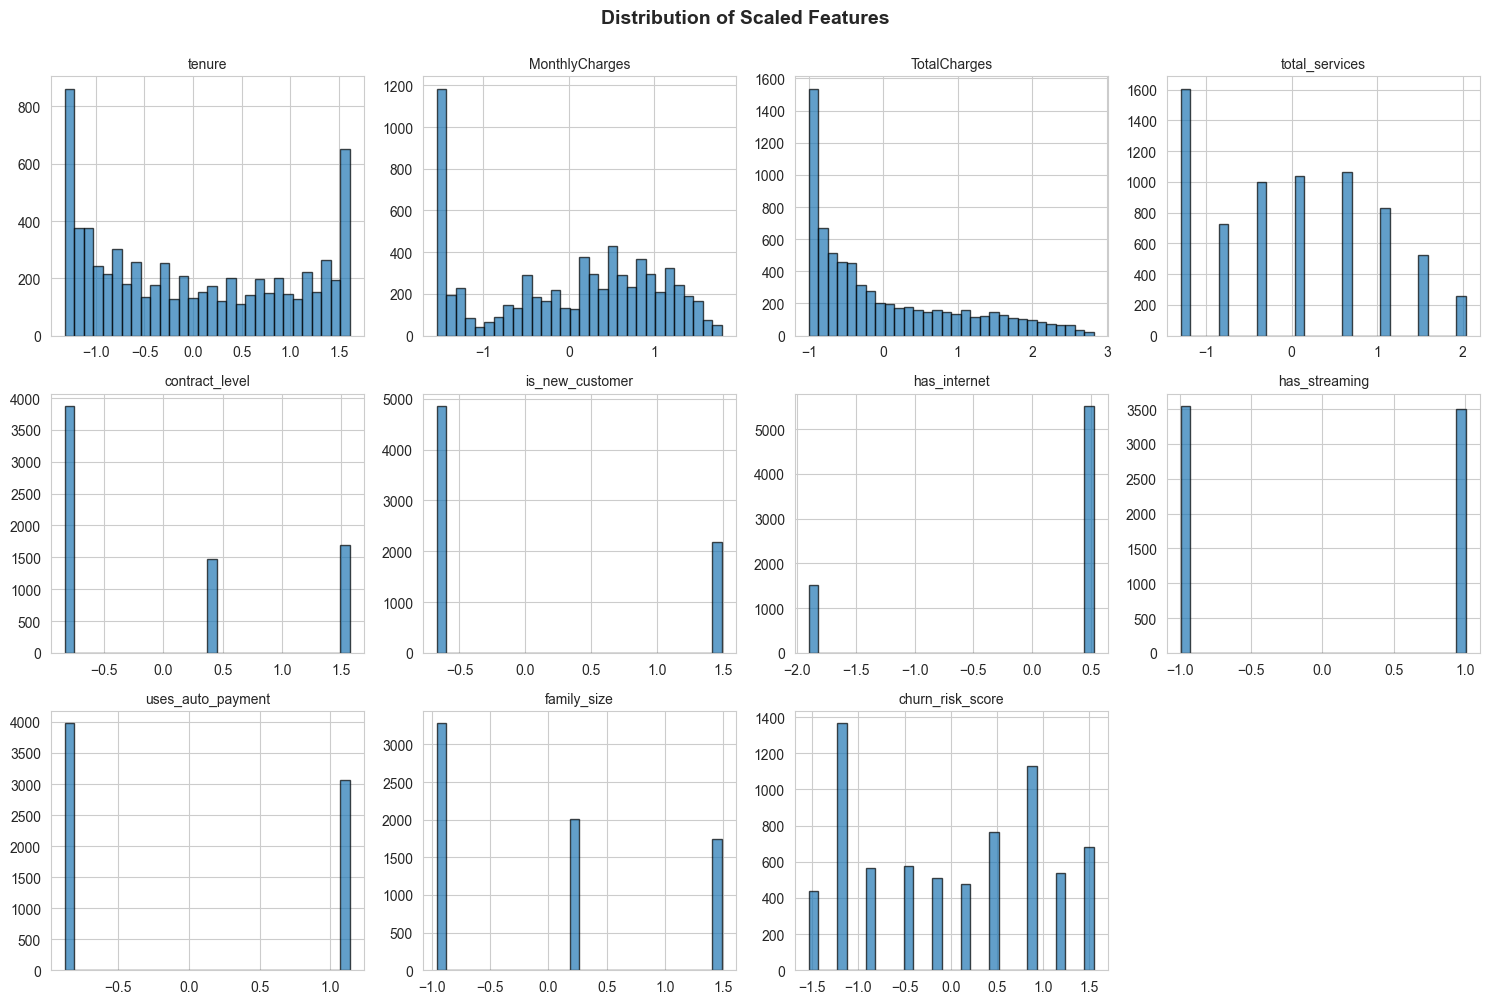


✅ Data is now ready for clustering!


In [3]:
# Scale the features
print("SCALING FEATURES")
print("="*50)

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
df_scaled = scaler.fit_transform(df_cluster)

# Convert back to DataFrame for easier handling
df_scaled = pd.DataFrame(df_scaled, columns=clustering_features)

print("✅ Features scaled successfully!")
print(f"\nScaled data shape: {df_scaled.shape}")
print("\nScaled feature statistics (mean should be ~0, std should be ~1):")
print(df_scaled.describe().round(2))

# Visualize distribution of scaled features
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(clustering_features):
    df_scaled[col].hist(bins=30, ax=axes[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Hide the last empty subplot
axes[-1].axis('off')

plt.suptitle('Distribution of Scaled Features', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n✅ Data is now ready for clustering!")

FINDING OPTIMAL NUMBER OF CLUSTERS
K=2: Inertia = 53327.35
K=3: Inertia = 39233.37
K=4: Inertia = 32907.35
K=5: Inertia = 29006.97
K=6: Inertia = 26339.17
K=7: Inertia = 24247.12
K=8: Inertia = 22641.55
K=9: Inertia = 21634.72
K=10: Inertia = 20079.76


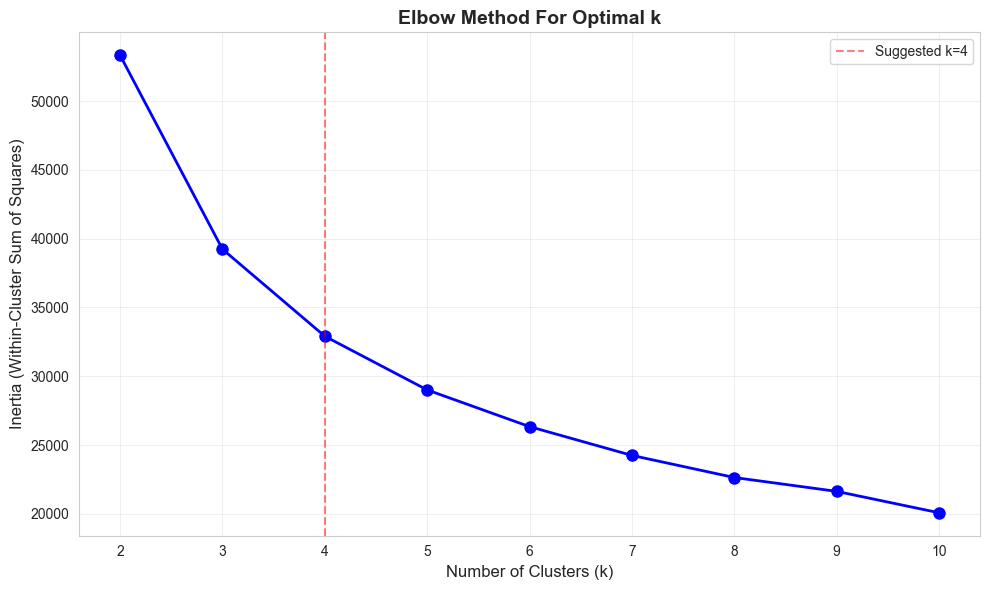


💡 The 'elbow' is where the curve starts to flatten.
   Based on the plot, k=4 or k=5 clusters appears optimal.


In [4]:
# Find optimal number of clusters using Elbow Method
print("FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*50)

# Calculate inertia (within-cluster sum of squares) for different k values
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    print(f"K={k}: Inertia = {kmeans.inertia_:.2f}")

# Plot the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method For Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)

# Mark the elbow point (typically around k=4 or k=5)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Suggested k=4')
plt.legend()
plt.tight_layout()
plt.show()

print("\n💡 The 'elbow' is where the curve starts to flatten.")
print("   Based on the plot, k=4 or k=5 clusters appears optimal.")

CREATING CUSTOMER SEGMENTS
✅ K-Means clustering completed!

Cluster distribution:
cluster
0    1957
1    1838
2    1178
3    2070
Name: count, dtype: int64


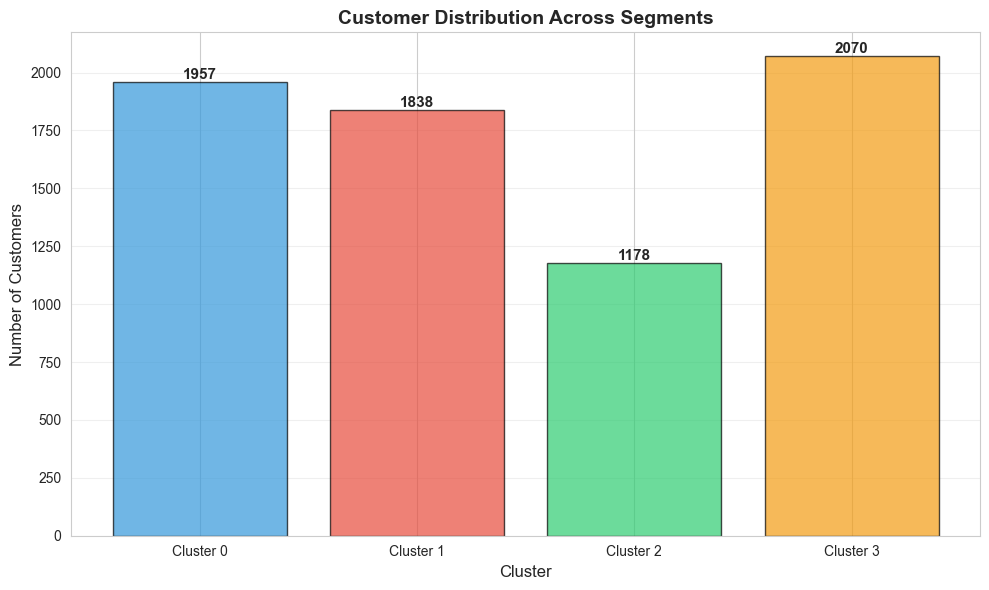


✅ Customers segmented into 4 clusters!


In [5]:
# Create customer segments using K-Means
print("CREATING CUSTOMER SEGMENTS")
print("="*50)

# Apply K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_scaled)

print("✅ K-Means clustering completed!")
print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())

# Visualize cluster distribution
plt.figure(figsize=(10, 6))
cluster_counts = df['cluster'].value_counts().sort_index()
bars = plt.bar(cluster_counts.index, cluster_counts.values, 
               color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], 
               edgecolor='black', alpha=0.7)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Customer Distribution Across Segments', fontsize=14, fontweight='bold')
plt.xticks([0, 1, 2, 3], ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Customers segmented into 4 clusters!")

CUSTOMER SEGMENT PROFILING

Cluster Profiles (Average Values):
         tenure  MonthlyCharges  TotalCharges  total_services  contract_level  \
cluster                                                                         
0         31.44           76.23       2412.79            4.15            0.18   
1         59.90           87.63       5281.81            6.06            1.48   
2         39.68           21.86        882.75            1.06            1.44   
3          4.65           58.03        283.55            2.76            0.04   

         churn_risk_score  is_new_customer  has_long_contract  \
cluster                                                         
0                    5.33             0.00               0.17   
1                    1.38             0.00               0.94   
2                    2.51             0.11               0.88   
3                    7.55             0.99               0.03   

         uses_auto_payment  
cluster                     
0

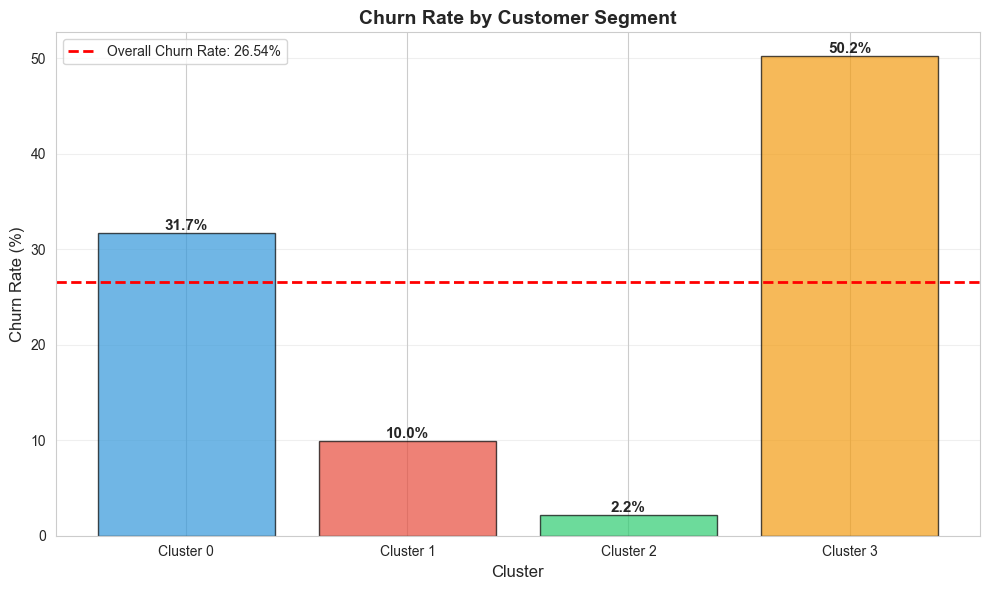

In [6]:
# Profile each cluster
print("CUSTOMER SEGMENT PROFILING")
print("="*60)

# Key features to profile
profile_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'total_services',
    'contract_level',
    'churn_risk_score',
    'is_new_customer',
    'has_long_contract',
    'uses_auto_payment'
]

# Calculate average values for each cluster
cluster_profiles = df.groupby('cluster')[profile_features].mean().round(2)

print("\nCluster Profiles (Average Values):")
print("="*60)
print(cluster_profiles)

# Calculate churn rate by cluster
print("\n" + "="*60)
print("CHURN RATE BY SEGMENT")
print("="*60)

df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
churn_by_cluster = df.groupby('cluster')['Churn_binary'].agg(['mean', 'sum', 'count'])
churn_by_cluster['mean'] = (churn_by_cluster['mean'] * 100).round(2)
churn_by_cluster.columns = ['Churn Rate (%)', 'Churned Customers', 'Total Customers']

print(churn_by_cluster)

# Visualize churn rate by cluster
plt.figure(figsize=(10, 6))
bars = plt.bar(churn_by_cluster.index, churn_by_cluster['Churn Rate (%)'],
               color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
               edgecolor='black', alpha=0.7)

plt.axhline(y=26.54, color='red', linestyle='--', linewidth=2, 
            label='Overall Churn Rate: 26.54%')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.title('Churn Rate by Customer Segment', fontsize=14, fontweight='bold')
plt.xticks([0, 1, 2, 3], ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
plt.legend()

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

NAMING CUSTOMER SEGMENTS
✅ Segments named successfully!

Segment Summary:

At-Risk Mid-Tier (Cluster 0):
  - Size: 1957 customers (27.8%)
  - Churn Rate: 31.73%

Loyal Premium (Cluster 1):
  - Size: 1838 customers (26.1%)
  - Churn Rate: 9.96%

Budget Committed (Cluster 2):
  - Size: 1178 customers (16.7%)
  - Churn Rate: 2.21%

High-Risk New (Cluster 3):
  - Size: 2070 customers (29.4%)
  - Churn Rate: 50.19%


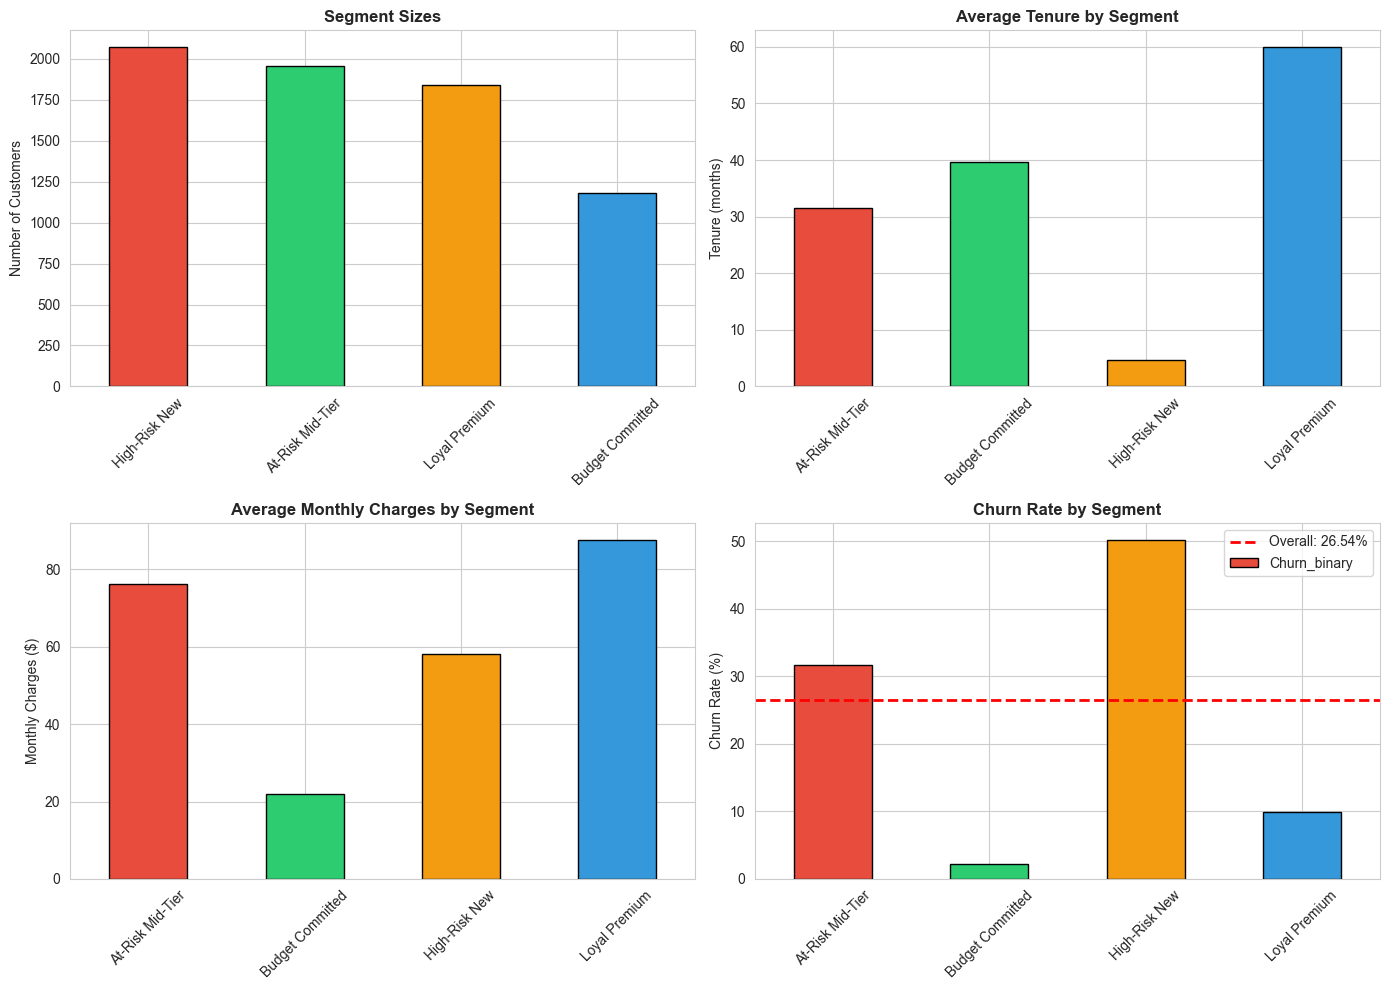

In [7]:
# Assign meaningful names to clusters
print("NAMING CUSTOMER SEGMENTS")
print("="*60)

cluster_names = {
    0: 'At-Risk Mid-Tier',
    1: 'Loyal Premium',
    2: 'Budget Committed', 
    3: 'High-Risk New'
}

df['segment_name'] = df['cluster'].map(cluster_names)

print("✅ Segments named successfully!")
print("\nSegment Summary:")
for cluster_id, name in cluster_names.items():
    count = len(df[df['cluster'] == cluster_id])
    churn_rate = df[df['cluster'] == cluster_id]['Churn_binary'].mean() * 100
    print(f"\n{name} (Cluster {cluster_id}):")
    print(f"  - Size: {count} customers ({count/len(df)*100:.1f}%)")
    print(f"  - Churn Rate: {churn_rate:.2f}%")

# Create a comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Segment size
ax1 = axes[0, 0]
segment_sizes = df['segment_name'].value_counts()
colors = ['#e74c3c', '#2ecc71', '#f39c12', '#3498db']
segment_sizes.plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('Segment Sizes', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Customers')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)

# 2. Average tenure by segment
ax2 = axes[0, 1]
df.groupby('segment_name')['tenure'].mean().plot(kind='bar', ax=ax2, color=colors, edgecolor='black')
ax2.set_title('Average Tenure by Segment', fontsize=12, fontweight='bold')
ax2.set_ylabel('Tenure (months)')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=45)

# 3. Average monthly charges
ax3 = axes[1, 0]
df.groupby('segment_name')['MonthlyCharges'].mean().plot(kind='bar', ax=ax3, color=colors, edgecolor='black')
ax3.set_title('Average Monthly Charges by Segment', fontsize=12, fontweight='bold')
ax3.set_ylabel('Monthly Charges ($)')
ax3.set_xlabel('')
ax3.tick_params(axis='x', rotation=45)

# 4. Churn rate comparison
ax4 = axes[1, 1]
churn_rates = df.groupby('segment_name')['Churn_binary'].mean() * 100
churn_rates.plot(kind='bar', ax=ax4, color=colors, edgecolor='black')
ax4.axhline(y=26.54, color='red', linestyle='--', linewidth=2, label='Overall: 26.54%')
ax4.set_title('Churn Rate by Segment', fontsize=12, fontweight='bold')
ax4.set_ylabel('Churn Rate (%)')
ax4.set_xlabel('')
ax4.tick_params(axis='x', rotation=45)
ax4.legend()

plt.tight_layout()
plt.show()

In [8]:
# Save the segmented dataset
df.to_csv('../data/processed/telco_churn_segmented.csv', index=False)

print("✅ Segmented dataset saved!")
print("   Location: data/processed/telco_churn_segmented.csv")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

# Create a summary report
print("\n" + "="*60)
print("CUSTOMER SEGMENTATION - FINAL SUMMARY")
print("="*60)

summary = df.groupby('segment_name').agg({
    'customerID': 'count',
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'TotalCharges': 'mean',
    'total_services': 'mean',
    'churn_risk_score': 'mean',
    'Churn_binary': 'mean'
}).round(2)

summary.columns = ['Count', 'Avg Tenure', 'Avg Monthly $', 'Avg Total $', 'Avg Services', 'Risk Score', 'Churn Rate']
summary['Churn Rate'] = (summary['Churn Rate'] * 100).round(2)

print("\n", summary)



✅ Segmented dataset saved!
   Location: data/processed/telco_churn_segmented.csv
   Rows: 7043
   Columns: 53

CUSTOMER SEGMENTATION - FINAL SUMMARY

                   Count  Avg Tenure  Avg Monthly $  Avg Total $  Avg Services  \
segment_name                                                                    
At-Risk Mid-Tier   1957       31.44          76.23      2412.79          4.15   
Budget Committed   1178       39.68          21.86       882.75          1.06   
High-Risk New      2070        4.65          58.03       283.55          2.76   
Loyal Premium      1838       59.90          87.63      5281.81          6.06   

                  Risk Score  Churn Rate  
segment_name                              
At-Risk Mid-Tier        5.33        32.0  
Budget Committed        2.51         2.0  
High-Risk New           7.55        50.0  
Loyal Premium           1.38        10.0  
